# 07 — Functional Interpretability



This notebook visualises and interprets the final functional classification results

without retraining the heavy models from the final modelling notebooks.
It combines:

- class-level spectral structure

- FPCA / FPLS score-space separation

- distance-based interpretability

- linear-model weight functions

- raw vs Gaussian-smoothed comparisons



Main goals:

1. load saved interpretability payloads from the final functional and smoothing notebooks

2. visualise global class differences

3. visualise FPCA and FPLS class separation

4. visualise a nearest-neighbour example

5. visualise local and global distance contribution curves

6. visualise functional logistic regression and linear SVM weight curves

7. compare raw and smoothed class curves

8. compare raw and smoothed weight curves



Main exported outputs:

- coefficient_curves_raw.csv

- coefficient_curves_smoothing.csv

- top_logreg_regions_raw.csv

- top_svm_regions_raw.csv

- fig_class_mean_spectra_raw.svg

- fig_mean_difference_raw.svg

- fig_fpca_scatter.svg

- fig_fpls_scatter.svg

- fig_nearest_neighbour_example.svg

- fig_local_distance_contribution.svg

- fig_global_distance_contribution.svg

- fig_beta_logreg_raw.svg

- fig_beta_svm_raw.svg

- fig_beta_compare_raw.svg

- fig_class_mean_spectra_raw_vs_smoothed.svg

- fig_mean_difference_raw_vs_smoothed.svg

- fig_beta_compare_smoothed.svg
 

In [115]:
from __future__ import annotations

import warnings
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import pairwise_distances

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Configuration

In [116]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "og_data"

FINAL_RESULTS_DIR = BASE_DIR / "results" / "04_final_functional_models"
SMOOTHING_RESULTS_DIR = BASE_DIR / "results" / "06_smoothing"
OUT_DIR = BASE_DIR / "results" / "07_interpretability"
OUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = DATA_DIR / "xp_sampled_spectra.csv"
FINAL_PAYLOAD_FILE = FINAL_RESULTS_DIR / "interpretability_payload.npz"
SMOOTHING_PAYLOAD_FILE = SMOOTHING_RESULTS_DIR / "smoothing_payload.npz"

TARGET_COL = "y"
SOURCE_ID_COL = "source_id"

CLASS_NAME_MAP = {
    0: "Nedvinarė",
    1: "Dvinarė",
}

MODEL_NAME_MAP = {
    "logreg": "Funkcinė logistinė regresija",
    "svm": "Funkcinis tiesinis SVM",
}

RAW_LABEL = "Neapdoroti duomenys"

## 2. Plot style

In [117]:
COLOR_PRIMARY = "#104A7E"     
COLOR_SECONDARY = "#78003F"  
COLOR_DARK = "#0D1530"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

SMOOTH_COLORS = {
    0.0: "#4A4A4A",
    2.0: "#6193CD",
    4.0: "#8DB3E2",
    6.0: "#B7D0EE",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def apply_clean_axes(ax, add_grid: bool = False, grid_axis: str = "y") -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if add_grid:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.6, alpha=0.5, color=COLOR_LIGHT)
    else:
        ax.grid(False)


def save_fig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close()


## 3. Helper functions

In [118]:
def l2_normalise_rows(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return X / norms

def normalise_curve_for_plot(beta):
    max_abs = np.max(np.abs(beta))
    if max_abs == 0:
        return beta
    return beta / max_abs


def infer_wavelength_columns(df: pd.DataFrame) -> list[str]:
    wl_cols = [c for c in df.columns if c.startswith("wl_")]
    if wl_cols:
        return sorted(wl_cols, key=lambda x: float(x.split("_")[1]))

    flux_cols = [c for c in df.columns if c.startswith("flux_")]
    if flux_cols:
        return sorted(flux_cols, key=lambda x: int(x.split("_")[1]))

    raise ValueError("Could not find spectral columns. Expected columns like wl_336 or flux_0.")


def build_global_knn_contribution(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    nn = pairwise_distances(X, X, metric="euclidean")
    np.fill_diagonal(nn, np.inf)
    nearest_idx = np.argmin(nn, axis=1)
    all_abs_diffs = np.abs(X - X[nearest_idx])
    return all_abs_diffs.mean(axis=0), nearest_idx


def top_weight_regions(
    wavelengths: np.ndarray,
    weights: np.ndarray,
    top_n: int = 15,
    weight_name: str = "weight",
) -> pd.DataFrame:
    df = pd.DataFrame({
        "wavelength": wavelengths,
        weight_name: weights,
        f"abs_{weight_name}": np.abs(weights),
    })
    return df.nlargest(top_n, f"abs_{weight_name}").reset_index(drop=True)


def safe_model_key(model_name: str) -> str:
    return (
        model_name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("=", "_")
        .replace(".", "_")
        .replace("-", "_")
    )


def extract_weight_curve_from_payload(payload, model_name: str) -> np.ndarray:
    key = f"weights_{safe_model_key(model_name)}"
    if key not in payload.files:
        raise KeyError(f"Missing weight curve in payload: {key}")
    return payload[key]


def sigma_label(sigma: float) -> str:
    return "Raw" if float(sigma) == 0.0 else f"σ={sigma:.1f}"


## 4. Load dataset and payloads

In [119]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

if not FINAL_PAYLOAD_FILE.exists():
    raise FileNotFoundError(f"Final interpretability payload not found: {FINAL_PAYLOAD_FILE}")

if not SMOOTHING_PAYLOAD_FILE.exists():
    raise FileNotFoundError(f"Smoothing payload not found: {SMOOTHING_PAYLOAD_FILE}")

df = pd.read_csv(INPUT_FILE)
final_payload = np.load(FINAL_PAYLOAD_FILE)
smoothing_payload = np.load(SMOOTHING_PAYLOAD_FILE)

wl_cols = infer_wavelength_columns(df)
wavelengths_from_df = np.array([float(col.split("_")[1]) for col in wl_cols], dtype=float)

X_raw_original = df[wl_cols].to_numpy(dtype=float)
X_l2 = l2_normalise_rows(X_raw_original)

wavelengths = final_payload["wavelengths"] if "wavelengths" in final_payload.files else wavelengths_from_df
y = final_payload["y"]

mean_0 = final_payload["mean_0"]
mean_1 = final_payload["mean_1"]
diff_10 = final_payload["diff_10"]

scores_fpca = final_payload["scores_fpca"]
scores_fpls = final_payload["scores_fpls"]

x_query = final_payload["x_query"]
closest_curve = final_payload["closest_curve"]
abs_diff = final_payload["abs_diff"]

beta_logreg = final_payload["beta_logreg"]
beta_svm = final_payload["beta_svm"]

mean_distance_contribution, nearest_idx = build_global_knn_contribution(X_l2)

sigmas = smoothing_payload["sigmas"].astype(float).tolist()
best_sigma_svm = float(smoothing_payload["best_sigma_svm"][0])
best_sigma_logreg = float(smoothing_payload["best_sigma_logreg"][0])

raw_mean_0_smooth = smoothing_payload["raw_mean_0"]
raw_mean_1_smooth = smoothing_payload["raw_mean_1"]
raw_diff_10_smooth = smoothing_payload["raw_diff_10"]

best_svm_mean_0 = smoothing_payload[f"smooth_mean_0_sigma_{best_sigma_svm}"]
best_svm_mean_1 = smoothing_payload[f"smooth_mean_1_sigma_{best_sigma_svm}"]
best_svm_diff_10 = smoothing_payload[f"smooth_diff_10_sigma_{best_sigma_svm}"]

best_logreg_mean_0 = smoothing_payload[f"smooth_mean_0_sigma_{best_sigma_logreg}"]
best_logreg_mean_1 = smoothing_payload[f"smooth_mean_1_sigma_{best_sigma_logreg}"]
best_logreg_diff_10 = smoothing_payload[f"smooth_diff_10_sigma_{best_sigma_logreg}"]

beta_svm_smoothed = extract_weight_curve_from_payload(
    smoothing_payload,
    f"Gaussian-smoothed + Functional linear SVM (sigma={best_sigma_svm})",
)

beta_logreg_smoothed = extract_weight_curve_from_payload(
    smoothing_payload,
    f"Gaussian-smoothed + Functional logistic regression (L2) (sigma={best_sigma_logreg})",
)

print("Loaded dataset shape:", df.shape)
print("Loaded final payload successfully.")
print("Loaded smoothing payload successfully.")
print("Number of wavelength bins:", len(wavelengths))
print("Available smoothing sigmas:", sigmas)
print("Best sigma for SVM:", best_sigma_svm)
print("Best sigma for logistic regression:", best_sigma_logreg)


Loaded dataset shape: (2815, 345)
Loaded final payload successfully.
Loaded smoothing payload successfully.
Number of wavelength bins: 343
Available smoothing sigmas: [2.0, 4.0, 6.0]
Best sigma for SVM: 6.0
Best sigma for logistic regression: 6.0


## 5. Rebuild nearest-neighbour context

In [120]:
query_match = np.argmin(np.sum((X_l2 - x_query.reshape(1, -1)) ** 2, axis=1))
nn_match = np.argmin(np.sum((X_l2 - closest_curve.reshape(1, -1)) ** 2, axis=1))

query_label = int(y[query_match])
nn_label = int(y[nn_match])

query_label_name = CLASS_NAME_MAP.get(query_label, str(query_label))
nn_label_name = CLASS_NAME_MAP.get(nn_label, str(nn_label))

query_source_id = df.iloc[query_match][SOURCE_ID_COL] if SOURCE_ID_COL in df.columns else np.nan
nn_source_id = df.iloc[nn_match][SOURCE_ID_COL] if SOURCE_ID_COL in df.columns else np.nan

nn_table = pd.DataFrame({
    "query_index": [query_match],
    "query_source_id": [query_source_id],
    "query_label": [query_label],
    "query_label_name": [query_label_name],
    "neighbour_index": [nn_match],
    "neighbour_source_id": [nn_source_id],
    "neighbour_label": [nn_label],
    "neighbour_label_name": [nn_label_name],
    "euclidean_distance": [float(np.linalg.norm(x_query - closest_curve))],
})

display(nn_table)


,query_index,query_source_id,query_label,query_label_name,neighbour_index,neighbour_source_id,neighbour_label,neighbour_label_name,euclidean_distance
0,47,1.465880e+17,1,Dvinarė,2399,6.381104e+18,1,Dvinarė,0.047313


## 6. Coefficient diagnostics

In [121]:
coef_df_raw = pd.DataFrame({
    "wavelength": wavelengths,
    "beta_logreg_raw": beta_logreg,
    "beta_svm_raw": beta_svm,
    "abs_beta_logreg_raw": np.abs(beta_logreg),
    "abs_beta_svm_raw": np.abs(beta_svm),
})

coef_df_smoothing = pd.DataFrame({
    "wavelength": wavelengths,
    "beta_logreg_raw": beta_logreg,
    f"beta_logreg_sigma_{best_sigma_logreg}": beta_logreg_smoothed,
    "beta_svm_raw": beta_svm,
    f"beta_svm_sigma_{best_sigma_svm}": beta_svm_smoothed,
})

top_logreg = top_weight_regions(
    wavelengths=wavelengths,
    weights=beta_logreg,
    top_n=15,
    weight_name="beta_logreg_raw",
)

top_svm = top_weight_regions(
    wavelengths=wavelengths,
    weights=beta_svm,
    top_n=15,
    weight_name="beta_svm_raw",
)

print("\n=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINĖ LOGISTINĖ REGRESIJA ===")
display(top_logreg)

print("\n=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINIS TIESINIS SVM ===")
display(top_svm)



=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINĖ LOGISTINĖ REGRESIJA ===


,wavelength,beta_logreg_raw,abs_beta_logreg_raw
0,1020.0,0.145990,0.145990
1,1000.0,0.141776,0.141776
2,998.0,0.141642,0.141642
3,972.0,0.140373,0.140373
4,974.0,0.138672,0.138672
5,996.0,0.138409,0.138409
6,970.0,0.137382,0.137382
7,1002.0,0.137003,0.137003
8,994.0,0.133204,0.133204
9,976.0,0.132702,0.132702



=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINIS TIESINIS SVM ===


,wavelength,beta_svm_raw,abs_beta_svm_raw
0,1020.0,0.170357,0.170357
1,974.0,0.110800,0.110800
2,972.0,0.110324,0.110324
3,1000.0,0.107294,0.107294
4,976.0,0.104418,0.104418
5,970.0,0.103424,0.103424
6,1002.0,0.103348,0.103348
7,998.0,0.102301,0.102301
8,942.0,0.095136,0.095136
9,944.0,0.094444,0.094444


## 7. Plot: raw class mean spectra

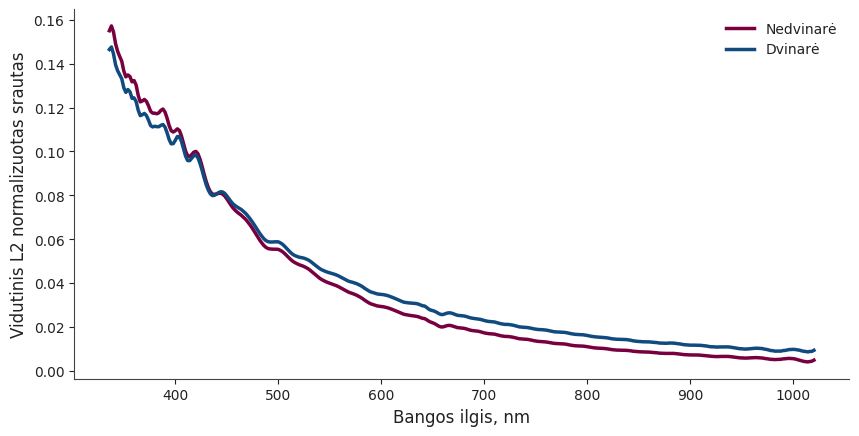

In [122]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_0, linewidth=2.5, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_1, linewidth=2.5, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 8. Plot: raw mean spectral difference

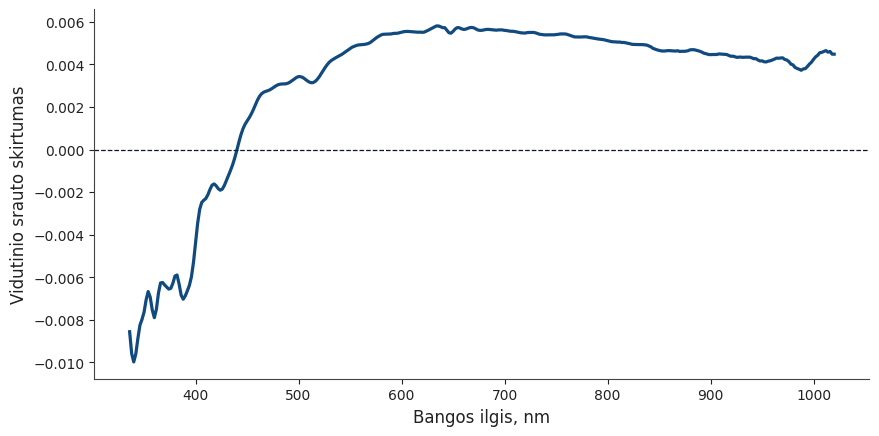

In [123]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, diff_10, linewidth=2.3, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinio srauto skirtumas")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 9. Plot: FPCA class separation

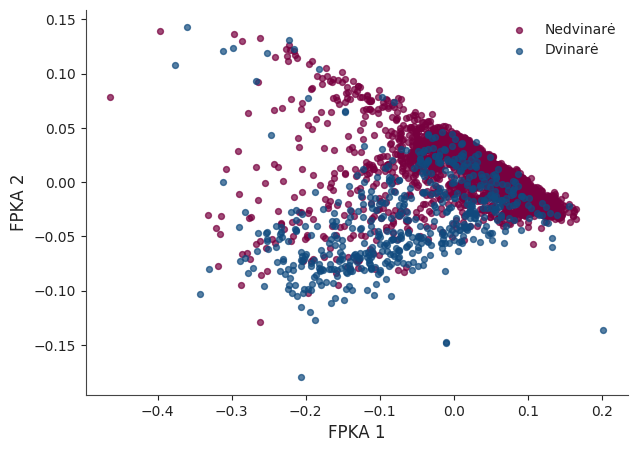

In [124]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    scores_fpca[y == 0, 0], scores_fpca[y == 0, 1],
    s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY
)
ax.scatter(
    scores_fpca[y == 1, 0], scores_fpca[y == 1, 1],
    s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY
)

ax.set_xlabel("FPKA 1")
ax.set_ylabel("FPKA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 10. Plot: FPLS class separation

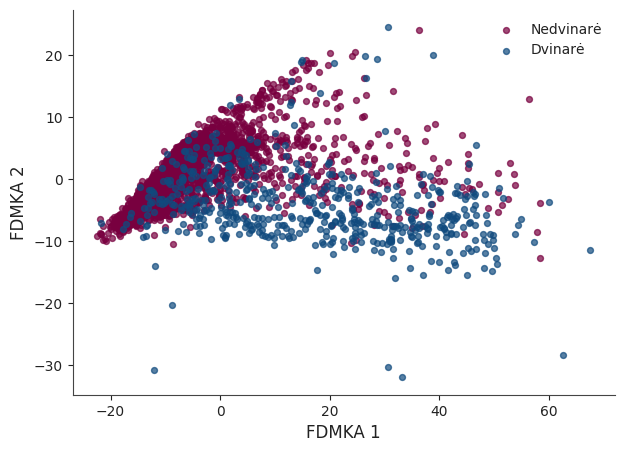

In [125]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    scores_fpls[y == 0, 0], scores_fpls[y == 0, 1],
    s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY
)
ax.scatter(
    scores_fpls[y == 1, 0], scores_fpls[y == 1, 1],
    s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY
)

ax.set_xlabel("FDMKA 1")
ax.set_ylabel("FDMKA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 11. Plot: nearest-neighbour example

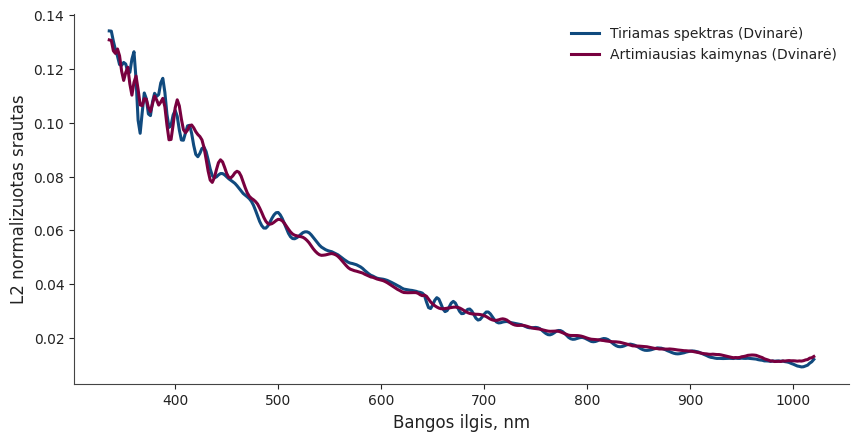

In [126]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, x_query, linewidth=2.2, color=COLOR_PRIMARY, label=f"Tiriamas spektras ({query_label_name})")
ax.plot(wavelengths, closest_curve, linewidth=2.2, color=COLOR_SECONDARY, label=f"Artimiausias kaimynas ({nn_label_name})")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 12. Plot: local distance contribution

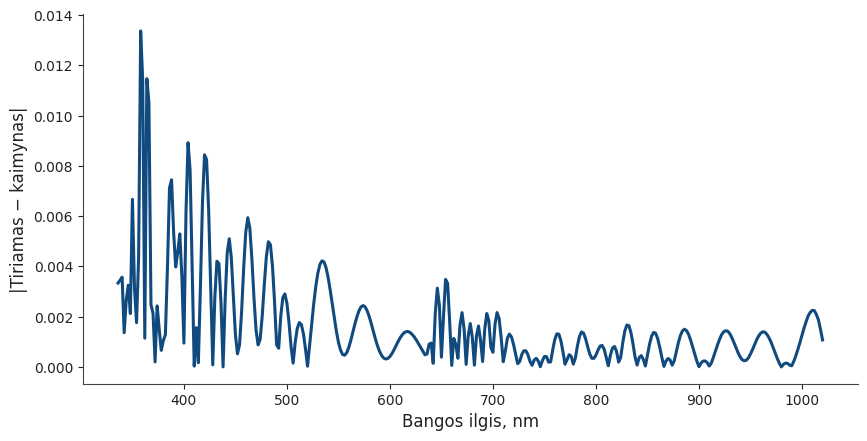

In [127]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, abs_diff, linewidth=2.2, color=COLOR_PRIMARY)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("|Tiriamas − kaimynas|")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 13. Plot: global distance contribution

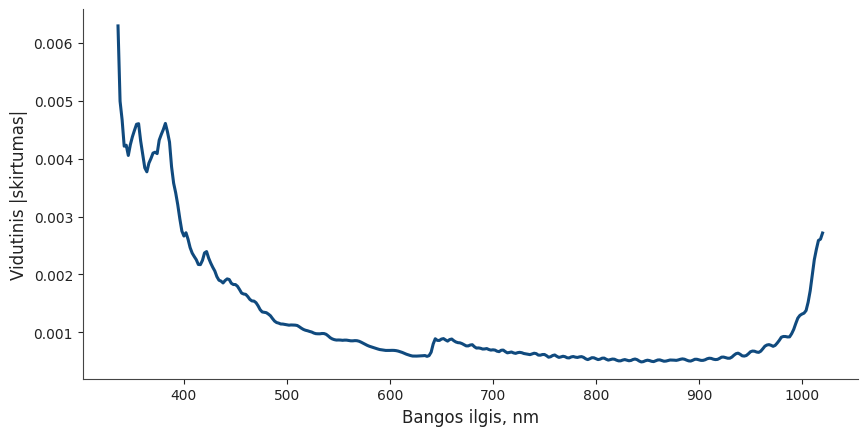

In [128]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_distance_contribution, linewidth=2.2, color=COLOR_PRIMARY)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis |skirtumas|")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 14. Plot: raw functional logistic regression weight function

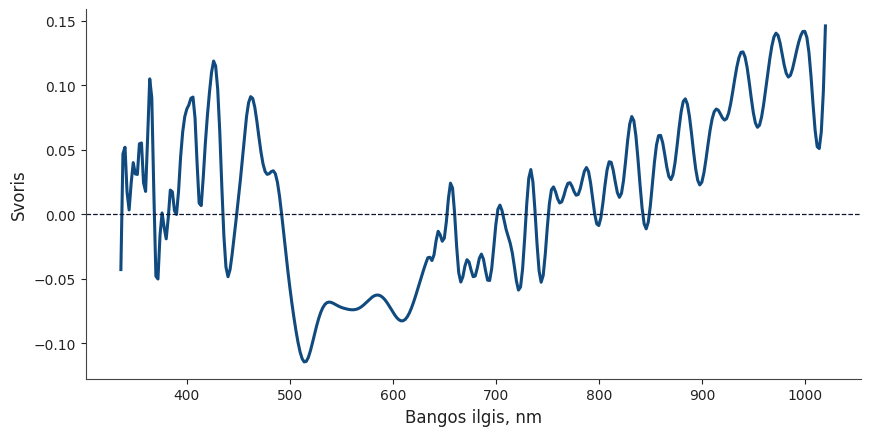

In [129]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_logreg, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 15. Plot: raw functional linear SVM weight function

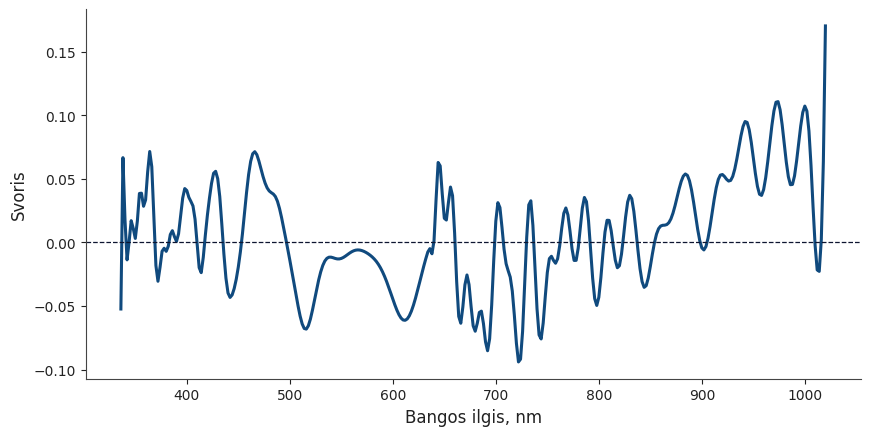

In [130]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_svm, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 16. Plot: comparison of raw linear-model weight curves

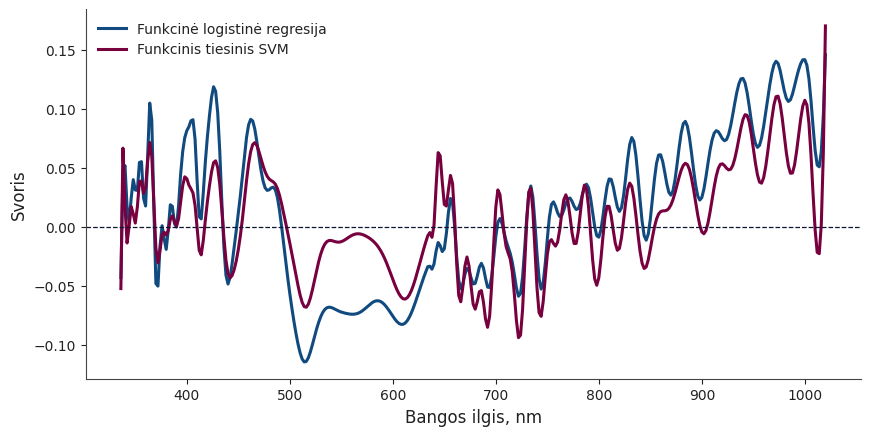

In [131]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_logreg, linewidth=2.2, color=COLOR_PRIMARY, label="Funkcinė logistinė regresija")
ax.plot(wavelengths, beta_svm, linewidth=2.2, color=COLOR_SECONDARY, label="Funkcinis tiesinis SVM")
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 17. Plot: raw vs smoothed class mean spectra

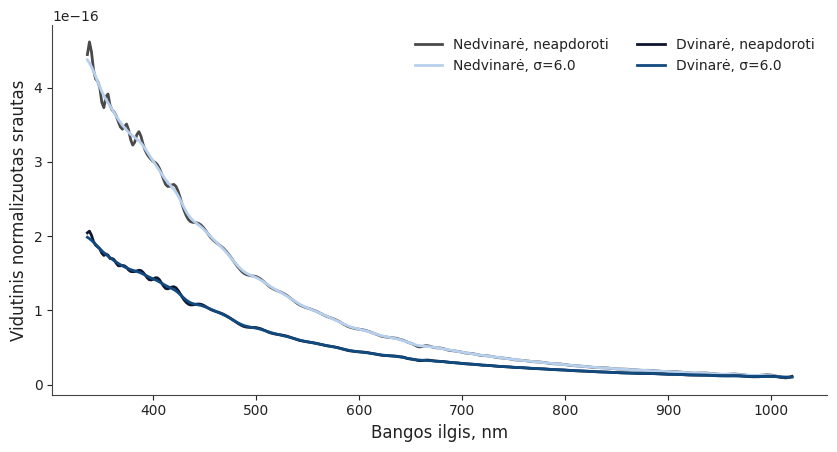

In [132]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, raw_mean_0_smooth, linewidth=2.0, color=SMOOTH_COLORS[0.0], label="Nedvinarė, neapdoroti")
ax.plot(wavelengths, best_svm_mean_0, linewidth=2.0, color=SMOOTH_COLORS[best_sigma_svm], label=f"Nedvinarė, σ={best_sigma_svm:.1f}")
ax.plot(wavelengths, raw_mean_1_smooth, linewidth=2.0, color=COLOR_DARK, label="Dvinarė, neapdoroti")
ax.plot(wavelengths, best_svm_mean_1, linewidth=2.0, color=COLOR_PRIMARY, label=f"Dvinarė, σ={best_sigma_svm:.1f}")


ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis normalizuotas srautas")
ax.legend(frameon=False, loc="best", ncol=2)
apply_clean_axes(ax, add_grid=False)
plt.show()


## 18. Plot: raw vs smoothed mean difference

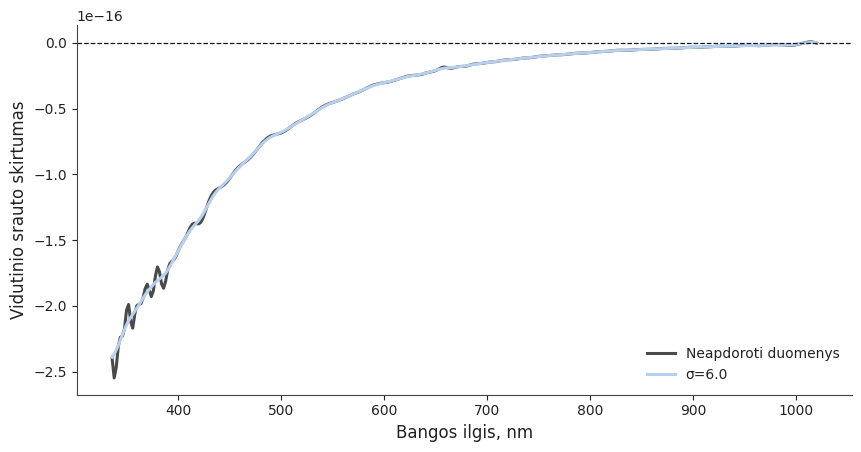

In [133]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, raw_diff_10_smooth, linewidth=2.2, color=SMOOTH_COLORS[0.0], label=RAW_LABEL)
ax.plot(wavelengths, best_svm_diff_10, linewidth=2.2, color=SMOOTH_COLORS[best_sigma_svm], label=f"σ={best_sigma_svm:.1f}")
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinio srauto skirtumas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 19. Plot: smoothed linear-model weight curves

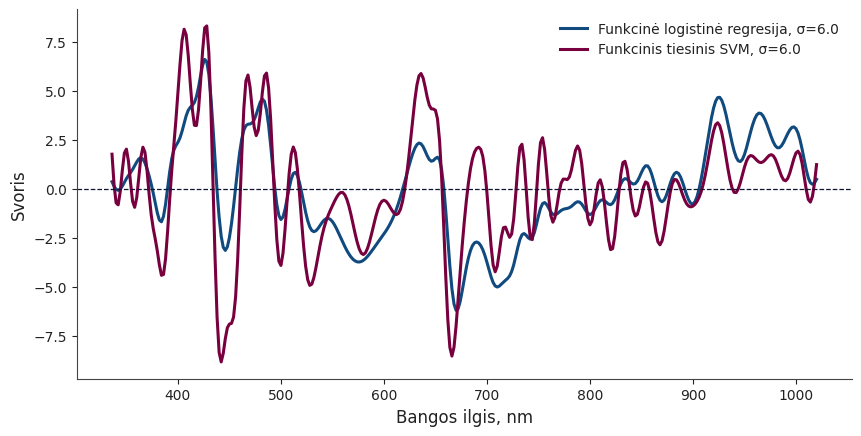

In [134]:
beta_logreg_smoothed_plot = beta_logreg_smoothed
beta_svm_smoothed_plot = beta_svm_smoothed

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    wavelengths,
    beta_logreg_smoothed_plot,
    linewidth=2.2,
    color=COLOR_PRIMARY,
    label=f"Funkcinė logistinė regresija, σ={best_sigma_logreg:.1f}",
)
ax.plot(
    wavelengths,
    beta_svm_smoothed_plot,
    linewidth=2.2,
    color=COLOR_SECONDARY,
    label=f"Funkcinis tiesinis SVM, σ={best_sigma_svm:.1f}",
)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()

## 20. Save main tables

In [135]:
coef_df_raw.to_csv(OUT_DIR / "coefficient_curves_raw.csv", index=False)
coef_df_smoothing.to_csv(OUT_DIR / "coefficient_curves_smoothing.csv", index=False)
top_logreg.to_csv(OUT_DIR / "top_logreg_regions_raw.csv", index=False)
top_svm.to_csv(OUT_DIR / "top_svm_regions_raw.csv", index=False)

print("Saved main CSV outputs to:", OUT_DIR)


Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_interpretability


## 21. Save figures

In [136]:
# Raw class mean spectra
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_0, linewidth=2.5, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_1, linewidth=2.5, color=COLOR_PRIMARY, label="Dvinarė")
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_class_mean_spectra_raw.svg")

# Raw mean difference
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, diff_10, linewidth=2.3, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinio srauto skirtumas")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_mean_difference_raw.svg")

# FPCA scatter
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(scores_fpca[y == 0, 0], scores_fpca[y == 0, 1], s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY)
ax.scatter(scores_fpca[y == 1, 0], scores_fpca[y == 1, 1], s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY)
ax.set_xlabel("FPKA 1")
ax.set_ylabel("FPKA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_fpca_scatter.svg")

# FPLS scatter
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(scores_fpls[y == 0, 0], scores_fpls[y == 0, 1], s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY)
ax.scatter(scores_fpls[y == 1, 0], scores_fpls[y == 1, 1], s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY)
ax.set_xlabel("FDMKA 1")
ax.set_ylabel("FDMKA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_fpls_scatter.svg")

# Nearest-neighbour example
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, x_query, linewidth=2.2, color=COLOR_PRIMARY, label=f"Tiriamas spektras ({query_label_name})")
ax.plot(wavelengths, closest_curve, linewidth=2.2, color=COLOR_SECONDARY, label=f"Artimiausias kaimynas ({nn_label_name})")
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_nearest_neighbour_example.svg")

# Local distance contribution
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, abs_diff, linewidth=2.2, color=COLOR_PRIMARY)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("|Tiriamas − kaimynas|")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_local_distance_contribution.svg")

# Global distance contribution
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_distance_contribution, linewidth=2.2, color=COLOR_PRIMARY)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis |skirtumas|")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_global_distance_contribution.svg")

# Raw logistic regression weights
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_logreg, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_beta_logreg_raw.svg")

# Raw SVM weights
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_svm, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_beta_svm_raw.svg")

# Raw weight comparison
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_logreg, linewidth=2.2, color=COLOR_PRIMARY, label="Funkcinė logistinė regresija")
ax.plot(wavelengths, beta_svm, linewidth=2.2, color=COLOR_SECONDARY, label="Funkcinis tiesinis SVM")
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_beta_compare_raw.svg")

# Raw vs smoothed class means
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, raw_mean_0_smooth, linewidth=2.0, color=SMOOTH_COLORS[0.0], label="Nedvinarė, neapdoroti")
ax.plot(wavelengths, best_svm_mean_0, linewidth=2.0, color=SMOOTH_COLORS[best_sigma_svm], label=f"Nedvinarė, σ={best_sigma_svm:.1f}")
ax.plot(wavelengths, raw_mean_1_smooth, linewidth=2.0, color=COLOR_DARK, label="Dvinarė, neapdoroti")
ax.plot(wavelengths, best_svm_mean_1, linewidth=2.0, color=COLOR_PRIMARY, label=f"Dvinarė, σ={best_sigma_svm:.1f}")
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis normalizuotas srautas")
ax.legend(frameon=False, loc="best", ncol=2)
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_class_mean_spectra_raw_vs_smoothed.svg")

# Raw vs smoothed mean difference
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, raw_diff_10_smooth, linewidth=2.2, color=SMOOTH_COLORS[0.0], label=RAW_LABEL)
ax.plot(wavelengths, best_svm_diff_10, linewidth=2.2, color=SMOOTH_COLORS[best_sigma_svm], label=f"σ={best_sigma_svm:.1f}")
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinio srauto skirtumas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_mean_difference_raw_vs_smoothed.svg")

# Smoothed weight comparison
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    wavelengths,
    beta_logreg_smoothed,
    linewidth=2.2,
    color=COLOR_PRIMARY,
    label=f"Funkcinė logistinė regresija, σ={best_sigma_logreg:.1f}",
)
ax.plot(
    wavelengths,
    beta_svm_smoothed,
    linewidth=2.2,
    color=COLOR_SECONDARY,
    label=f"Funkcinis tiesinis SVM, σ={best_sigma_svm:.1f}",
)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_beta_compare_smoothed.svg")

print("Saved figure outputs to:", OUT_DIR)


Saved figure outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_interpretability
